In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

df             = pd.read_csv('../data/processed/featured.csv')
artist_df      = pd.read_csv('../data/outputs/artist_platform_identity.csv')
model_summary  = pd.read_csv('../data/outputs/model_summary.csv')

print(f"✅ All data loaded!")

✅ All data loaded!


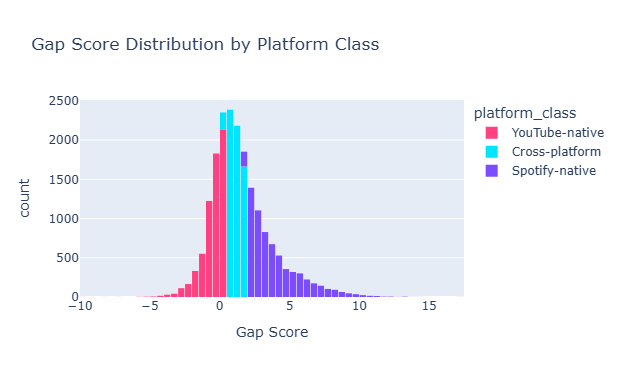

✅ Saved!


In [2]:
fig = px.histogram(
    df, x='gap_score', nbins=60,
    color='platform_class',
    title='Gap Score Distribution by Platform Class',
    labels={'gap_score': 'Gap Score', 'count': 'Number of Songs'},
    color_discrete_map={
        'Spotify-native' : '#7c4dff',
        'Cross-platform' : '#00e5ff',
        'YouTube-native' : '#ff4081'
    }
)
fig.update_layout(bargap=0.1)
fig.show()
fig.write_html('../reports/figures/gap_distribution.html')
print("✅ Saved!")

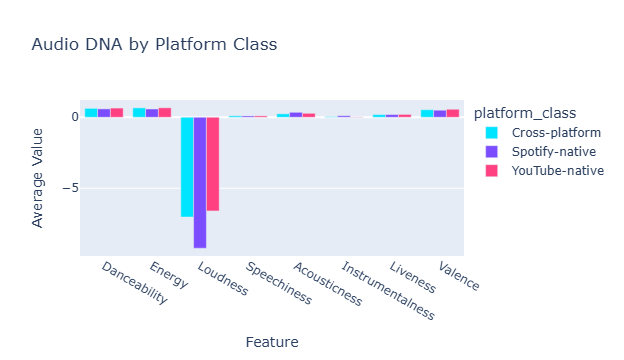

✅ Saved!


In [3]:
audio_cols = ['Danceability','Energy','Loudness','Speechiness',
              'Acousticness','Instrumentalness','Liveness','Valence']

audio_dna = df.groupby('platform_class')[audio_cols].mean().reset_index()
audio_dna_melted = audio_dna.melt(
    id_vars='platform_class',
    var_name='Feature',
    value_name='Average Value'
)

fig = px.bar(
    audio_dna_melted,
    x='Feature', y='Average Value',
    color='platform_class',
    barmode='group',
    title='Audio DNA by Platform Class',
    color_discrete_map={
        'Spotify-native' : '#7c4dff',
        'Cross-platform' : '#00e5ff',
        'YouTube-native' : '#ff4081'
    }
)
fig.show()
fig.write_html('../reports/figures/audio_dna.html')
print("✅ Saved!")

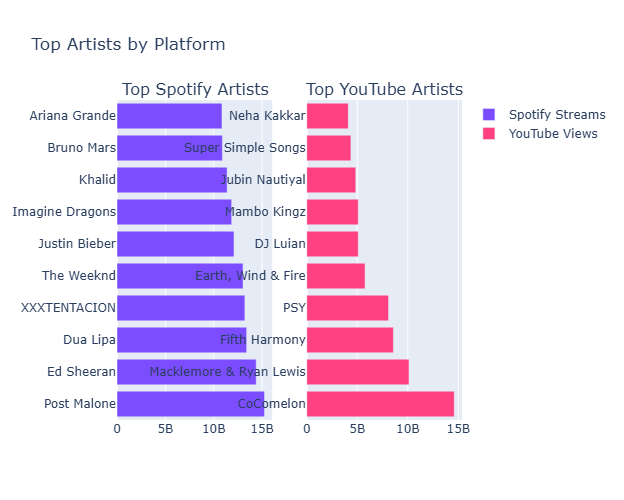

✅ Saved!


In [4]:
top_spotify  = artist_df[artist_df['platform_identity']=='Spotify Artist'].nlargest(10, 'total_streams')
top_youtube  = artist_df[artist_df['platform_identity']=='YouTube Artist'].nlargest(10, 'total_views')

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Top Spotify Artists', 'Top YouTube Artists'))

fig.add_trace(go.Bar(
    x=top_spotify['total_streams'],
    y=top_spotify['Artist'],
    orientation='h',
    marker_color='#7c4dff',
    name='Spotify Streams'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=top_youtube['total_views'],
    y=top_youtube['Artist'],
    orientation='h',
    marker_color='#ff4081',
    name='YouTube Views'
), row=1, col=2)

fig.update_layout(title='Top Artists by Platform', height=500)
fig.show()
fig.write_html('../reports/figures/top_artists_platform.html')
print("✅ Saved!")

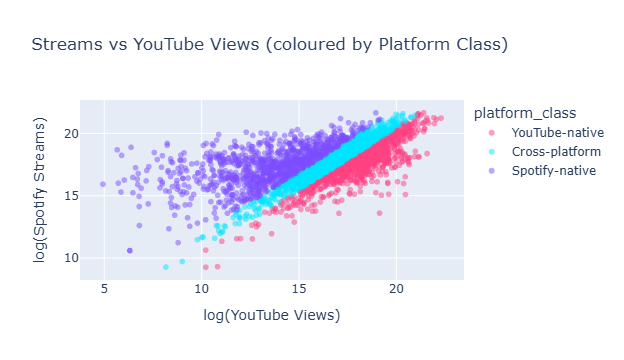

✅ Saved!


In [5]:
sample = df.sample(3000, random_state=42)

fig = px.scatter(
    sample,
    x='log_views', y='log_streams',
    color='platform_class',
    hover_data=['Artist', 'Track'],
    title='Streams vs YouTube Views (coloured by Platform Class)',
    labels={
        'log_views'   : 'log(YouTube Views)',
        'log_streams' : 'log(Spotify Streams)'
    },
    color_discrete_map={
        'Spotify-native' : '#7c4dff',
        'Cross-platform' : '#00e5ff',
        'YouTube-native' : '#ff4081'
    },
    opacity=0.5
)
fig.show()
fig.write_html('../reports/figures/streams_vs_views.html')
print("✅ Saved!")

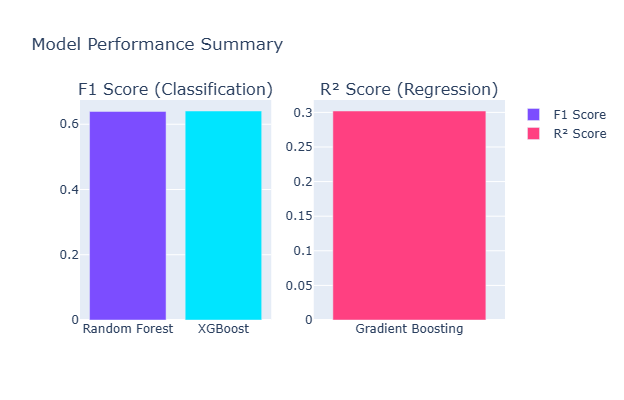

✅ Saved!


In [6]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('F1 Score (Classification)',
                                    'R² Score (Regression)'))

# Classification models
clf = model_summary[model_summary['Task']=='Classification']
fig.add_trace(go.Bar(
    x=clf['Model'], y=clf['Score'],
    marker_color=['#7c4dff','#00e5ff'],
    name='F1 Score'
), row=1, col=1)

# Regression model
reg = model_summary[model_summary['Task']=='Regression']
fig.add_trace(go.Bar(
    x=reg['Model'], y=reg['Score'],
    marker_color=['#ff4081'],
    name='R² Score'
), row=1, col=2)

fig.update_layout(title='Model Performance Summary', height=400)
fig.show()
fig.write_html('../reports/figures/model_performance.html')
print("✅ Saved!")

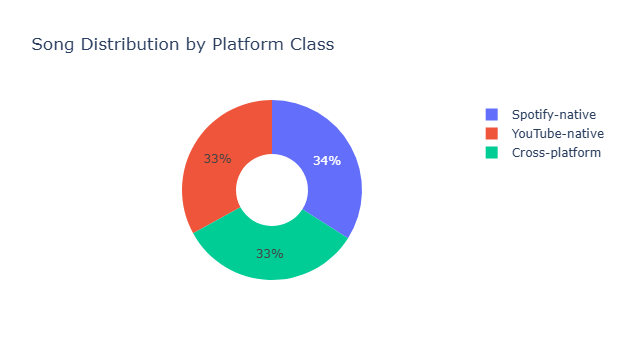

✅ Saved!


In [7]:
counts = df['platform_class'].value_counts().reset_index()
counts.columns = ['Platform', 'Count']

fig = px.pie(
    counts,
    names='Platform',
    values='Count',
    title='Song Distribution by Platform Class',
    color_discrete_map={
        'Spotify-native' : '#7c4dff',
        'Cross-platform' : '#00e5ff',
        'YouTube-native' : '#ff4081'
    },
    hole=0.4
)
fig.show()
fig.write_html('../reports/figures/platform_pie.html')
print("✅ Saved!")

In [9]:
# Combine all charts into one HTML file
dashboard_html = """
<!DOCTYPE html>
<html>
<head>
    <title>Music Popularity Intelligence Dashboard</title>
    <style>
        body  {{ font-family: Arial; background: #0f0f1a; color: white; padding: 20px; }}
        h1    {{ text-align: center; color: #7c4dff; }}
        h3    {{ color: #00e5ff; }}
        .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }}
        iframe {{ width: 100%; height: 450px; border: none; border-radius: 8px; }}
    </style>
</head>
<body>
    <h1>🎵 Music Popularity Intelligence Dashboard</h1>
    <h3>Cross-Platform Gap Analysis — Spotify vs YouTube</h3>
    <div class="grid">
        <iframe src="gap_distribution.html"></iframe>
        <iframe src="platform_pie.html"></iframe>
        <iframe src="audio_dna.html"></iframe>
        <iframe src="streams_vs_views.html"></iframe>
        <iframe src="top_artists_platform.html"></iframe>
        <iframe src="model_performance.html"></iframe>
    </div>
</body>
</html>
"""

with open('../reports/dashboard.html', 'w', encoding='utf-8') as f:
    f.write(dashboard_html)

print("✅ Full dashboard saved to reports/dashboard.html")
print("✅ Open this file in your browser to see everything!")

✅ Full dashboard saved to reports/dashboard.html
✅ Open this file in your browser to see everything!
